### PCA from full_v2.csv (feature exclusion by dropping of duplicate data from features)

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
df_pca = pd.read_csv('../dataset/pca_transformed_data_v2.csv')
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC64,PC65,PC66,PC67,PC68,PC69,PC70,PC71,Activity,subject
0,-5.383960,0.840098,1.371802,-1.697453,-0.972454,0.372223,0.667269,0.648175,-1.255301,0.347805,...,-0.215970,-0.910967,0.058841,-0.066793,0.605805,0.037834,0.260348,-0.727063,STANDING,1
1,-5.348016,0.857284,1.726519,-0.751878,-0.726136,-0.831305,-0.569199,-0.678363,-0.999667,-0.431817,...,-0.140061,-0.231977,-0.300848,0.098455,-0.192299,0.037348,0.098554,-0.303799,STANDING,1
2,-5.263130,0.608949,2.085375,-0.584750,-0.019100,0.017133,0.040167,0.072799,-0.242581,-0.199784,...,-0.059735,-0.124607,0.190060,-0.069405,-0.185923,0.106396,-0.096266,0.106103,STANDING,1
3,-5.488520,-0.119065,2.236513,-0.271997,-0.771325,-1.156456,-0.113606,-0.359962,0.401655,0.195824,...,-0.133177,0.178098,0.076741,-0.063363,-0.489024,0.112212,0.138759,0.141511,STANDING,1
4,-5.513019,-0.175920,2.397887,-0.288146,-0.462541,-0.410086,0.013335,0.011953,0.493933,0.124994,...,-0.058593,0.307647,-0.170470,-0.314672,-0.180030,0.067980,-0.023344,-0.200219,STANDING,1


In [8]:
X = df_pca[[f"PC{i}" for i in range(1, 70)]]  # Predictors (69 components)
y = df_pca["Activity"]                        # Target variable
groups = df_pca["subject"]

In [9]:
# Encode string labels (WALKING, SITTING, etc.) to 0, 1, 2...
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_pca["Activity"])

# 1. Outer Split: Hold out unseen subjects for final test evaluation
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss_outer.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]

In [10]:
# Initialize base model
xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.4],
    'min_child_weight': [1, 3, 5]
}

# 5-Fold Group Cross-Validation on training subjects
gkf = GroupKFold(n_splits=5)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,                  # Try 25 random combinations
    scoring='f1_macro',          # Optimizes for balanced class performance
    cv=gkf,                      # Respects subject boundaries during folds
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit search passing groups explicitly
search.fit(X_train, y_train, groups=groups_train)

print("Best Parameters:", search.best_params_)
print(f"Best Group Cross-Validation Macro F1: {search.best_score_:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.6}
Best Group Cross-Validation Macro F1: 0.9292


In [11]:
# Retrieve best model
best_model = search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(X_test)

# Convert integer predictions back to original activity names
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

print("\n--- Tuned XGBoost Classification Report (Unseen Subjects) ---")
print(classification_report(y_test_labels, y_pred_labels))


--- Tuned XGBoost Classification Report (Unseen Subjects) ---
                    precision    recall  f1-score   support

            LAYING       0.99      0.94      0.97       537
           SITTING       0.79      0.86      0.82       495
          STANDING       0.80      0.79      0.79       527
           WALKING       0.97      0.93      0.95       451
WALKING_DOWNSTAIRS       0.95      0.77      0.85       389
  WALKING_UPSTAIRS       0.81      0.98      0.89       429

          accuracy                           0.88      2828
         macro avg       0.89      0.88      0.88      2828
      weighted avg       0.88      0.88      0.88      2828



In [ ]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# 2. Get unique activity labels in alphabetical order (matching confusion_matrix default)
labels = sorted(y_test.unique())

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# Get indices for train and test sets based on Subject groups
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
# Initialize and train model
model = xgb.XGBClassifier(
    n_estimators=100,     # Number of boosting rounds (trees)
    max_depth=4,          # Maximum tree depth
    learning_rate=0.1,    # Step size shrinkage (eta) to prevent overfitting
    objective='binary:logistic', # Loss function for binary classification
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate on unseen subjects
y_pred = model.predict(X_test)

print("--- Classification Report (Unseen Subjects) ---")
print(classification_report(y_test, y_pred))

--- Classification Report (Unseen Subjects) ---
                    precision    recall  f1-score   support

            LAYING       0.99      0.99      0.99       537
           SITTING       0.75      0.80      0.77       495
          STANDING       0.81      0.75      0.78       527
           WALKING       0.96      0.91      0.93       451
WALKING_DOWNSTAIRS       0.93      0.71      0.81       389
  WALKING_UPSTAIRS       0.78      0.99      0.87       429

          accuracy                           0.86      2828
         macro avg       0.87      0.86      0.86      2828
      weighted avg       0.87      0.86      0.86      2828



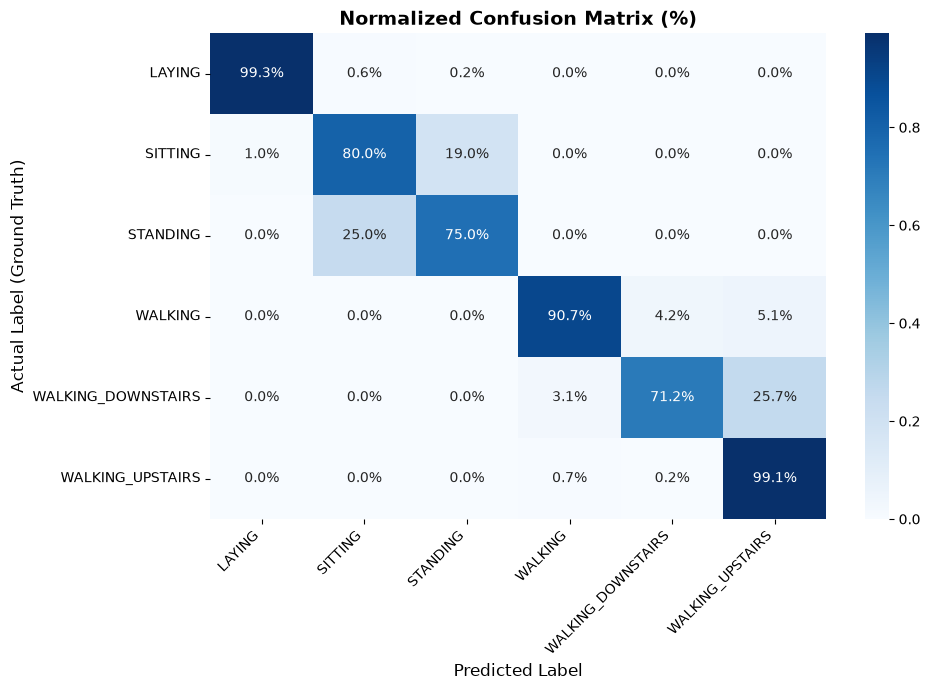

In [15]:
# Compute normalized matrix (percentages along rows)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# 2. Get unique activity labels in alphabetical order (matching confusion_matrix default)
labels = sorted(y_test.unique())

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.1%',              # Format as percentage (e.g., 70.2%)
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()